1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

2. Load Dataset

In [4]:
df = pd.read_csv("data/Raval Vashishth Divyangkumar - Dataset.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (121856, 40)


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655054,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631354537,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355638717,0.2021,674.0,1.0,0


3. Basic Info

In [5]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          121856 non-null  int64  
 1   Client_Income               118249 non-null  object 
 2   Car_Owned                   118275 non-null  float64
 3   Bike_Owned                  118232 non-null  float64
 4   Active_Loan                 118221 non-null  float64
 5   House_Own                   118195 non-null  float64
 6   Child_Count                 118218 non-null  float64
 7   Credit_Amount               118224 non-null  object 
 8   Loan_Annuity                117044 non-null  object 
 9   Accompany_Client            120110 non-null  object 
 10  Client_Income_Type          118155 non-null  object 
 11  Client_Education            118211 non-null  object 
 12  Client_Marital_Status       118383 non-null  object 
 13  Client_Gender 

,count,mean,std,min,25%,50%,75%,max
ID,121856.0,1.216093e+07,35176.941538,1.210000e+07,1.213046e+07,1.216093e+07,1.219139e+07,1.222186e+07
Car_Owned,118275.0,3.428535e-01,0.474665,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Bike_Owned,118232.0,3.322620e-01,0.471026,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Active_Loan,118221.0,4.991753e-01,0.500001,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
House_Own,118195.0,6.920597e-01,0.461644,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Child_Count,118218.0,4.177790e-01,0.728802,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
Own_House_Age,41761.0,1.215732e+01,12.056079,0.000000e+00,5.000000e+00,9.000000e+00,1.500000e+01,6.900000e+01
Mobile_Tag,121856.0,9.999918e-01,0.002865,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Homephone_Tag,121856.0,2.004989e-01,0.400375,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Workphone_Working,121856.0,2.812008e-01,0.449587,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


4. Missing Values Analysis

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Count"] > 0].head(20)

,Missing Count,Missing %
Own_House_Age,80095,65.729221
Score_Source_1,68835,56.488806
Social_Circle_Default,61928,50.820641
Client_Occupation,41435,34.003250
Score_Source_3,26921,22.092470
Credit_Bureau,18540,15.214680
ID_Days,5968,4.897584
Score_Source_2,5686,4.666163
Population_Region_Relative,4857,3.985852
Loan_Annuity,4812,3.948923


Visualization

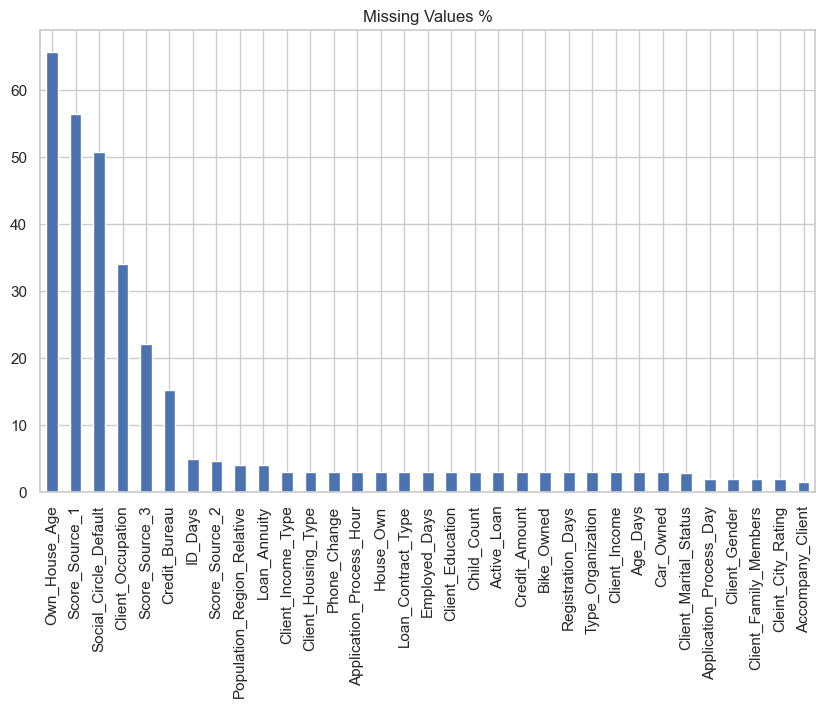

In [7]:
missing_percent[missing_percent > 0].plot(kind="bar")
plt.title("Missing Values %")
plt.show()

5. Target Variable Analysis

In [8]:
df['Default'].value_counts()
df['Default'].value_counts(normalize=True)

Default
0    0.919208
1    0.080792
Name: proportion, dtype: float64

Plot

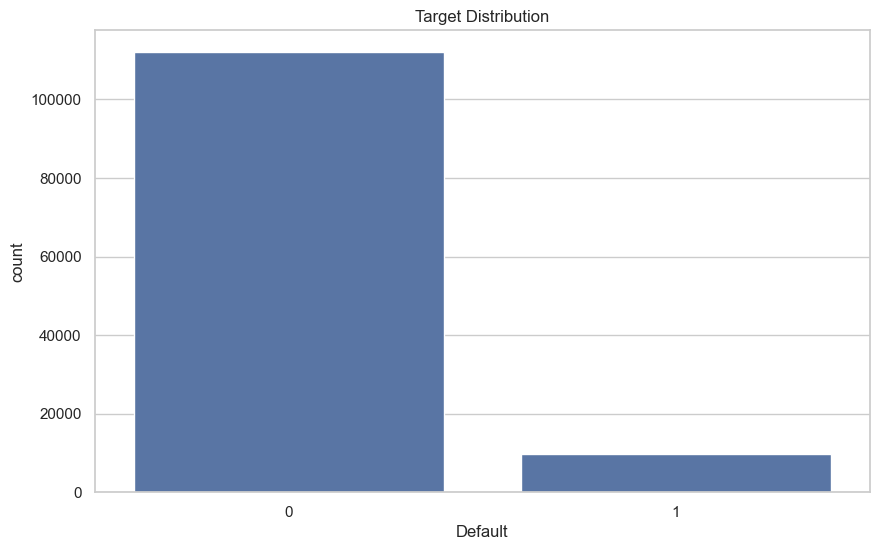

In [9]:
sns.countplot(x="Default", data=df)
plt.title("Target Distribution")
plt.show()

6. Separate Numerical & Categorical

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 20
Categorical: 20


7. Numerical Feature Analysis

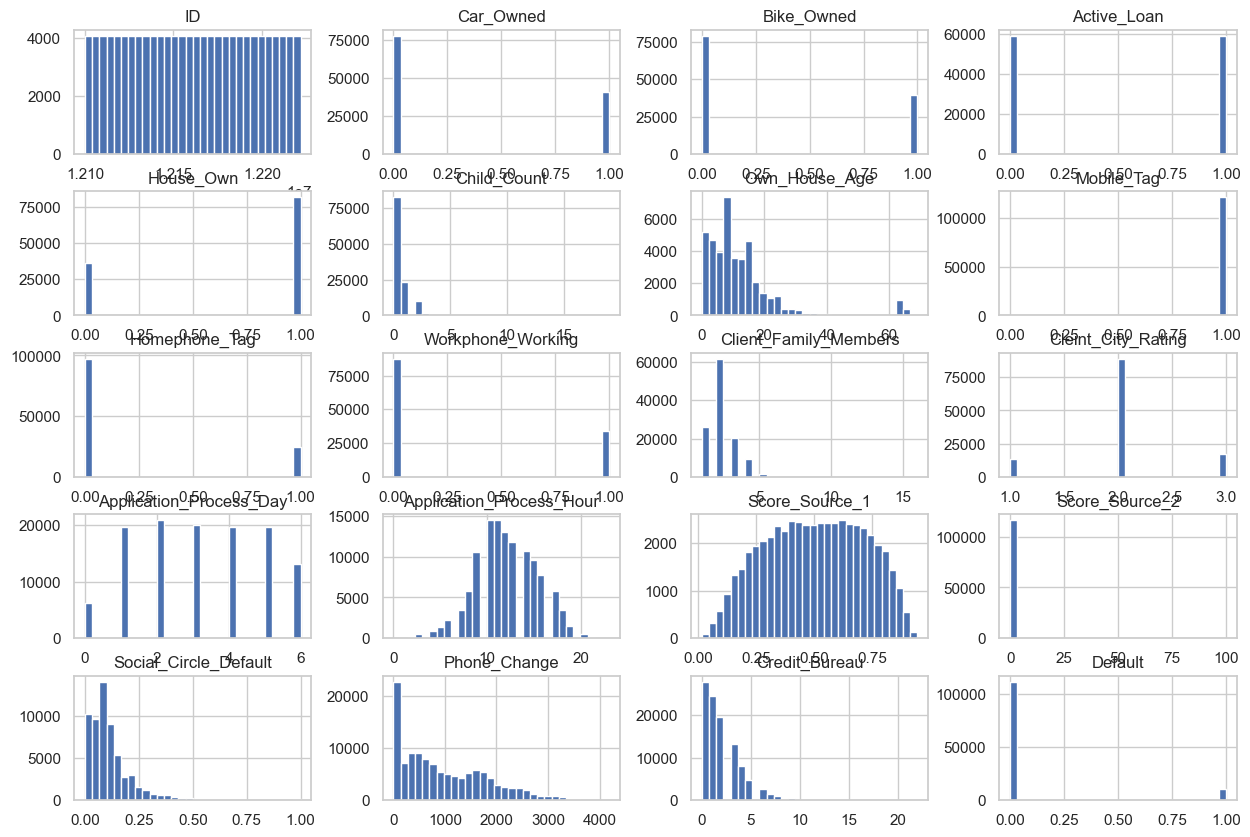

In [11]:
df[num_cols].hist(bins=30, figsize=(15,10))
plt.show()

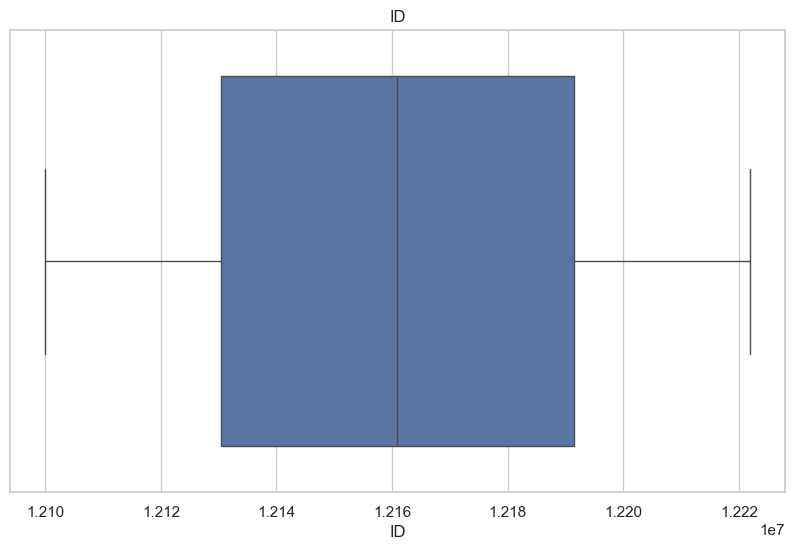

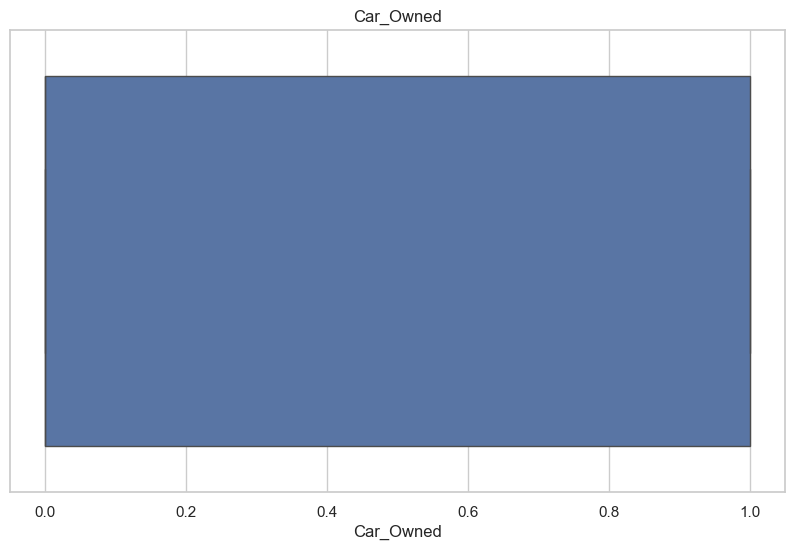

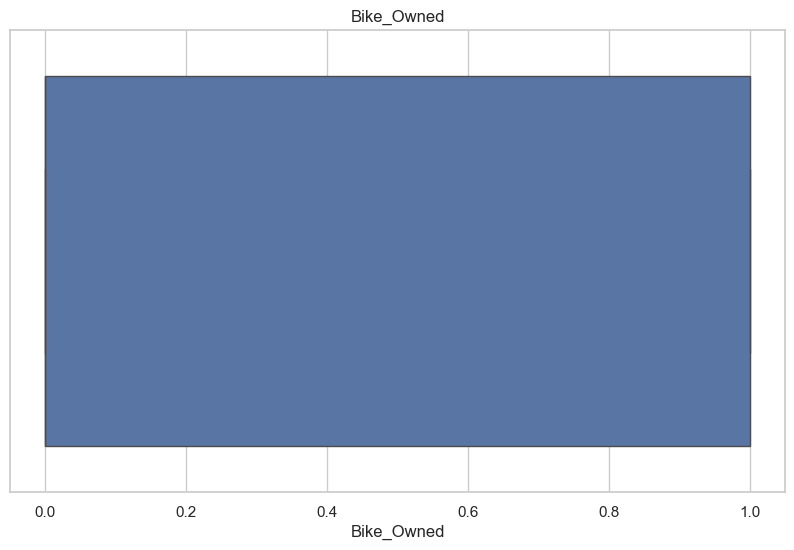

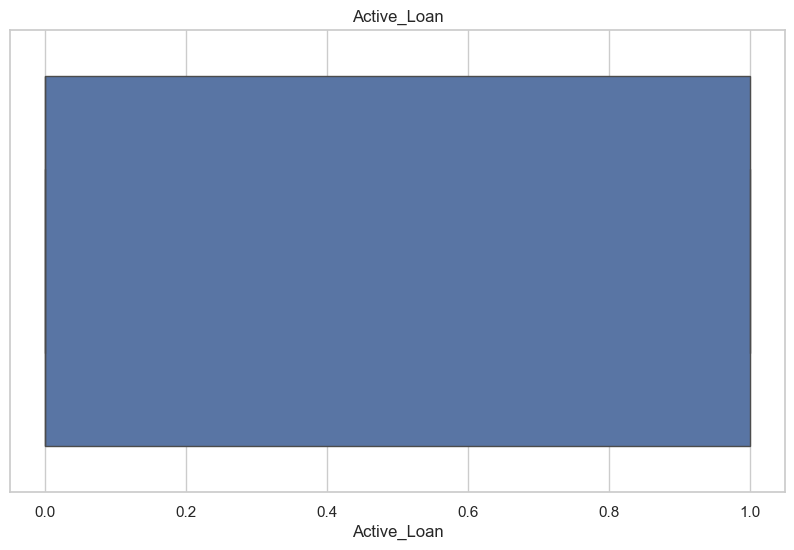

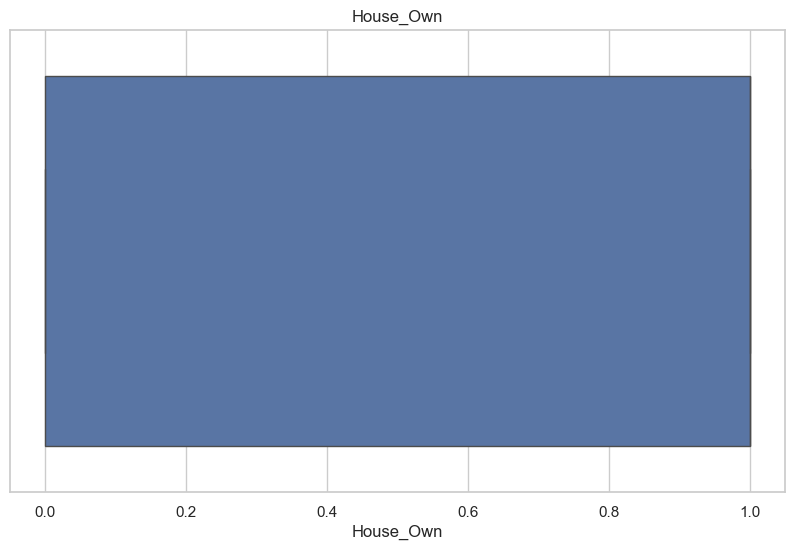

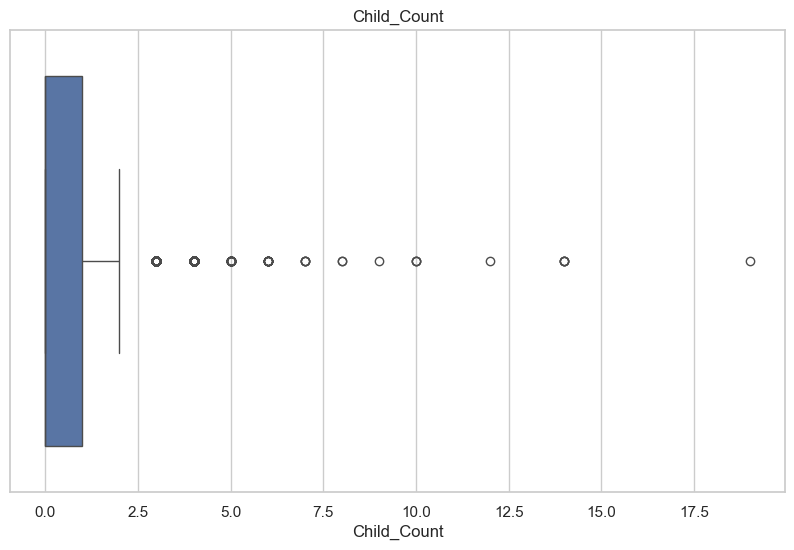

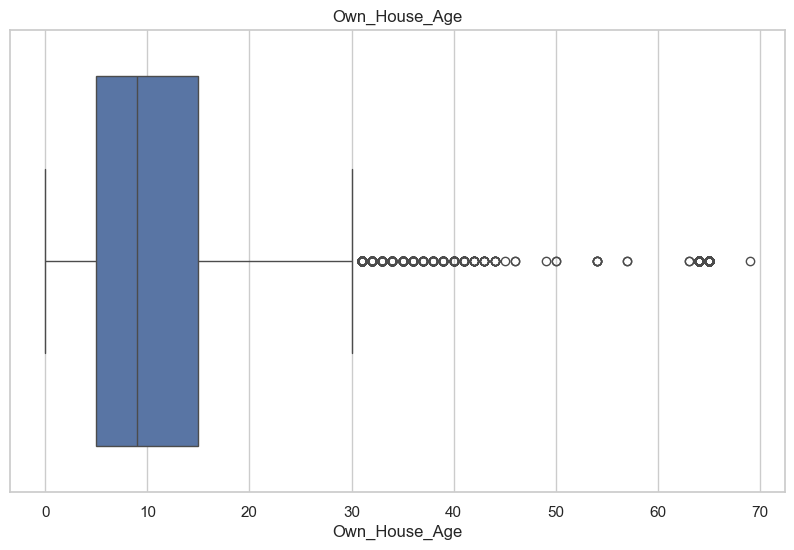

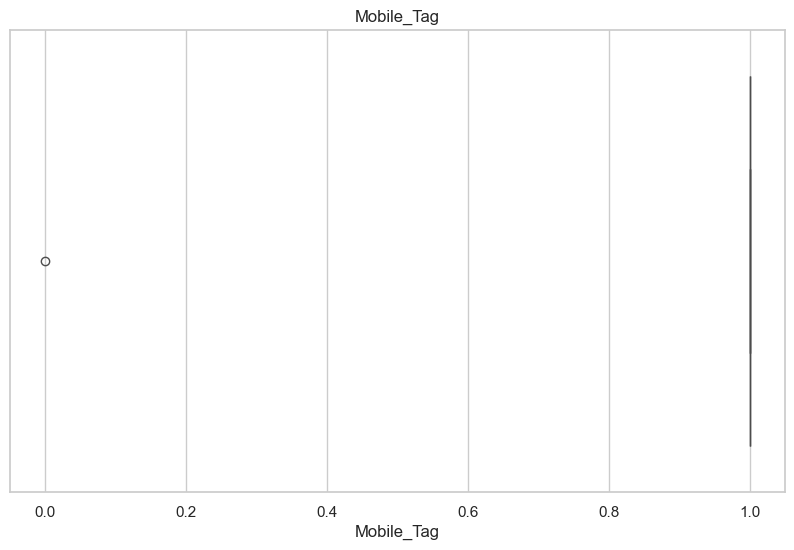

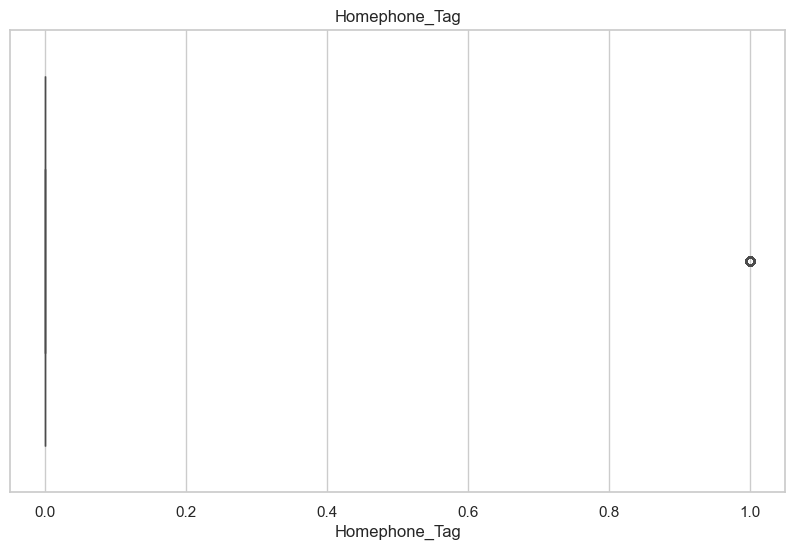

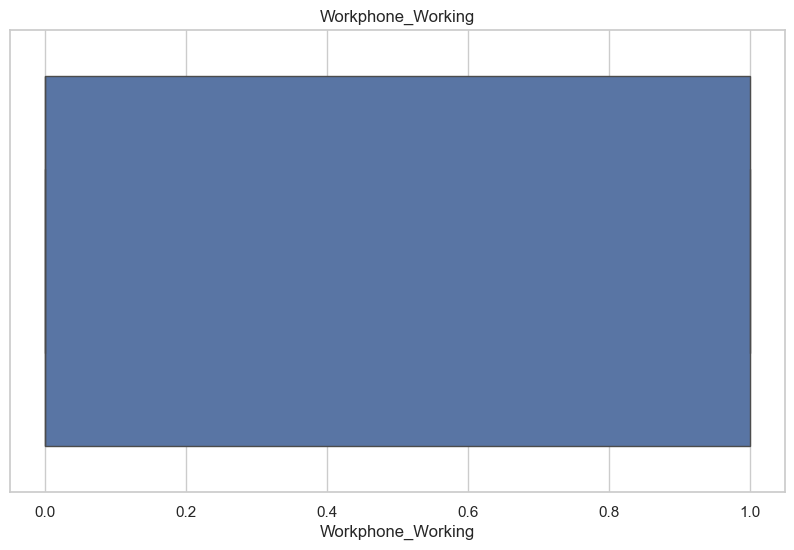

In [12]:
for col in num_cols[:10]:  # limit for readability
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

8. Correlation Analysis

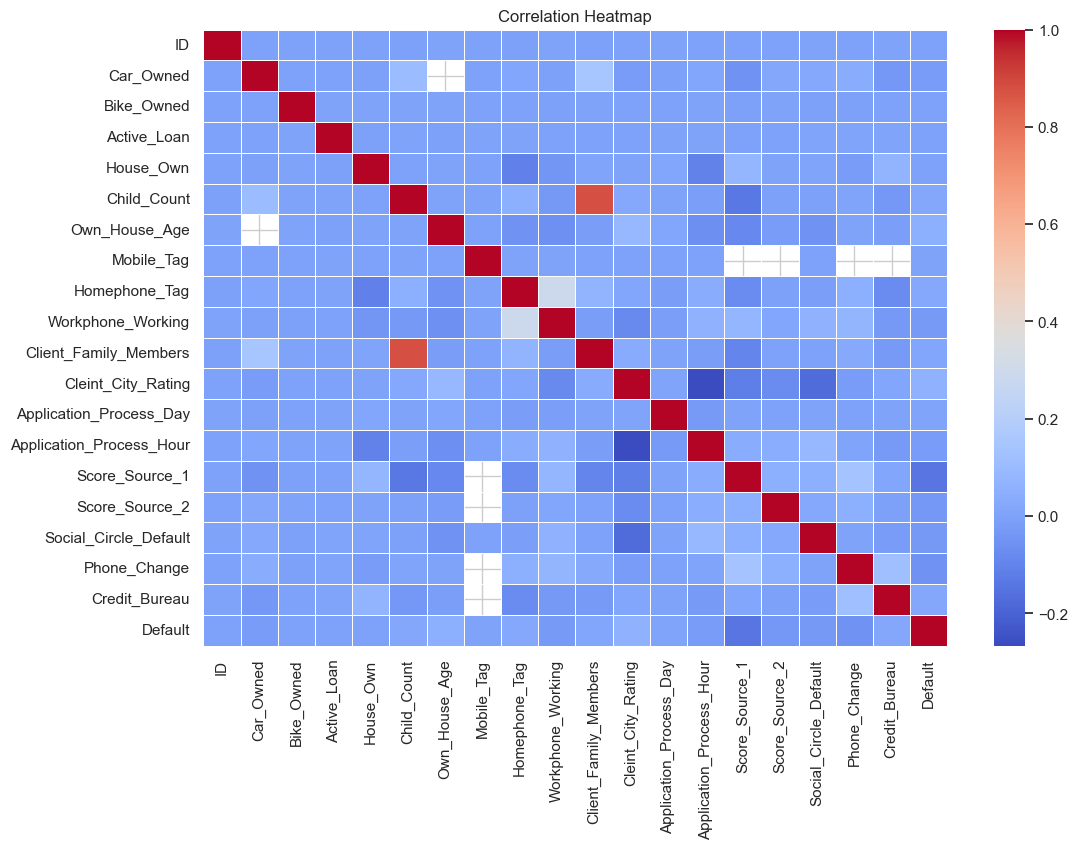

In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

9. Feature vs Target

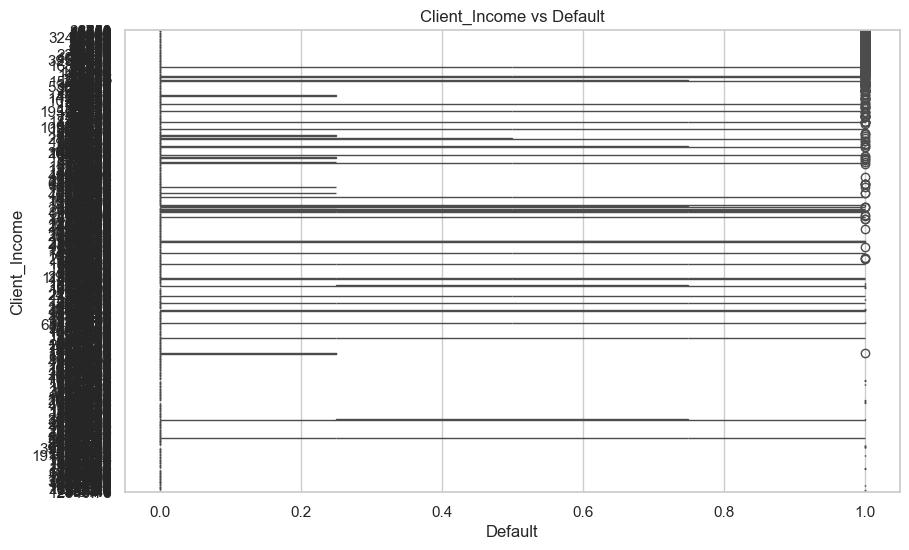

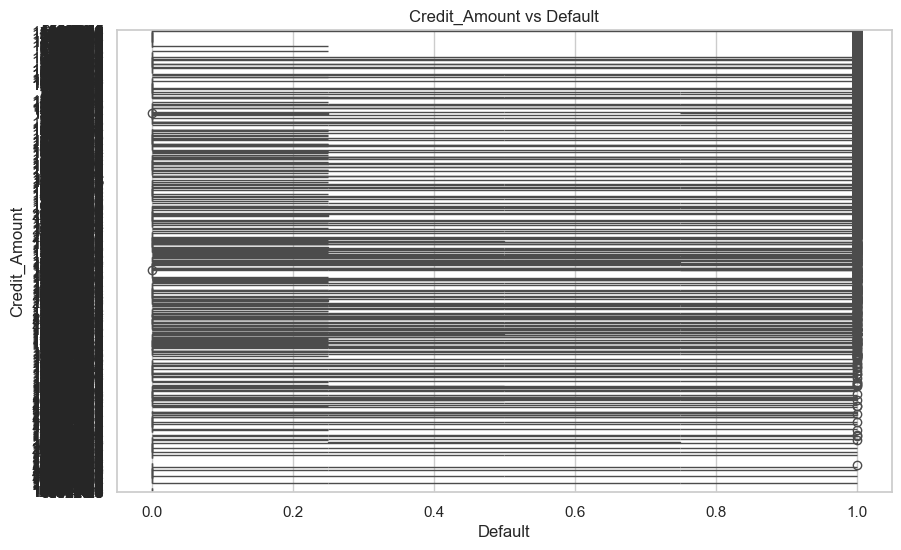

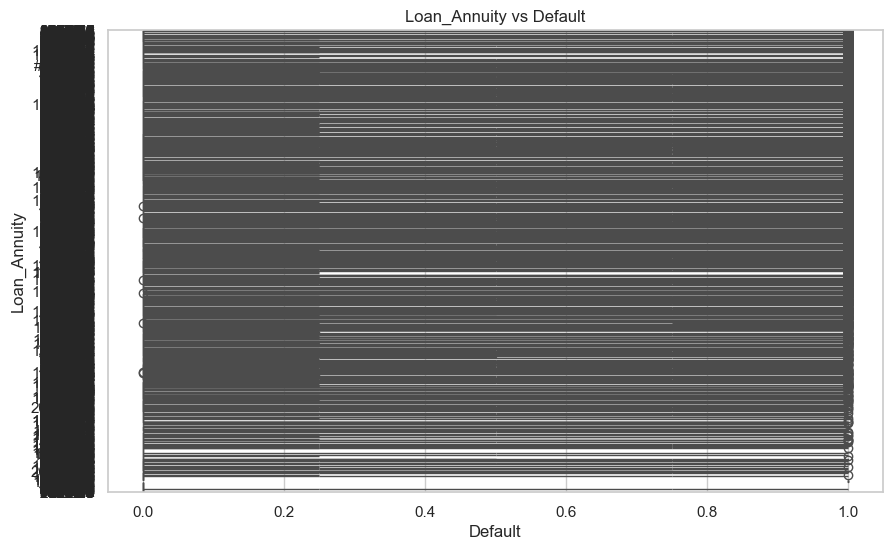

In [14]:
important_num = ['Client_Income', 'Credit_Amount', 'Loan_Annuity']

for col in important_num:
    sns.boxplot(x="Default", y=col, data=df)
    plt.title(f"{col} vs Default")
    plt.show()

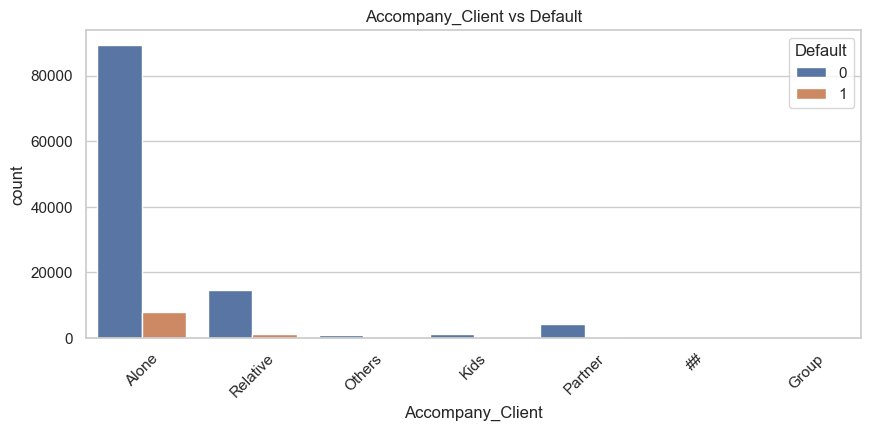

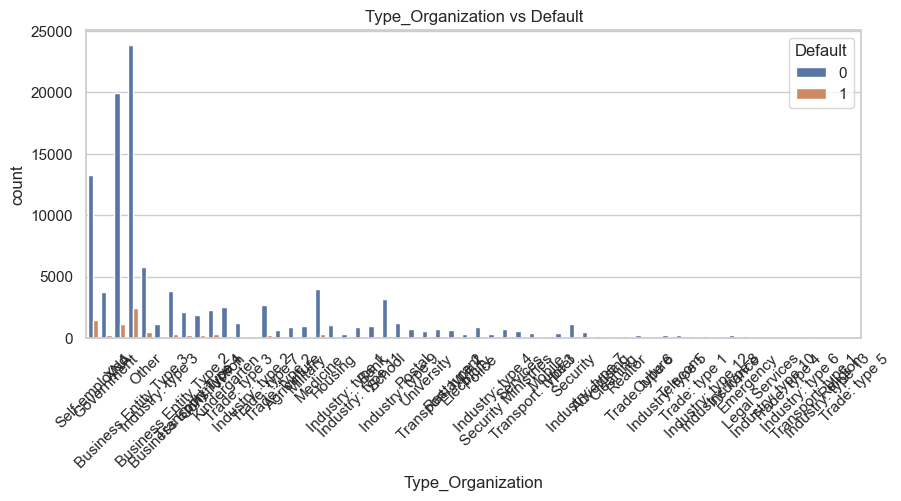

In [15]:
important_cat = ['Accompany_Client', 'Type_Organization']

for col in important_cat:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue="Default", data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Default")
    plt.show()

### Key Insights:

1. Dataset is imbalanced → requires SMOTE
2. High missing values in some columns → imputation needed
3. Strong features:
   - Credit Amount
   - Client Income
   - Loan Annuity
4. Derived features (ratios) show strong separation
5. Presence of outliers → scaling required